<a href="https://colab.research.google.com/github/Benguerine/ai-notebook/blob/main/CNN_IMDB_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Sentiment Analysis on IMDB Reviews using CNN
## Based on: *"Convolutional Neural Networks for Sentence Classification"* — Yoon Kim (2014)

---

### 📄 Paper Summary
Yoon Kim (2014) showed that a **simple CNN with one layer of convolution** on top of pre-trained word vectors achieves excellent performance on sentence classification tasks.

**Key ideas from the paper:**
- Use multiple filter sizes (e.g., 3, 4, 5) to capture different n-gram patterns
- Apply **max-over-time pooling** after convolution
- Use **dropout + L2 regularization** to prevent overfitting
- The model can use: static embeddings, non-static (fine-tuned), or random embeddings

### 🎯 Task
Binary classification: **Positive 😊** vs **Negative 😞** movie review

### 📦 Dataset
IMDB dataset from Keras — 25,000 training + 25,000 test movie reviews

---

## 📚 Step 1: Install & Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"✅ Keras version      : {keras.__version__}")
print(f"✅ NumPy version      : {np.__version__}")

✅ TensorFlow version : 2.19.0
✅ Keras version      : 3.10.0
✅ NumPy version      : 2.0.2


## ⚙️ Step 2: Hyperparameters & Configuration

All settings in **one place** — easy to tweak!

In [2]:


# --- Data ---
VOCAB_SIZE    = 10_000
MAX_LEN       = 200

# --- Embedding ---
EMBED_DIM     = 128



FILTER_SIZES  = [3, 4, 5]
NUM_FILTERS   = 128

# --- Regularization ---
DROPOUT_RATE  = 0.5
L2_LAMBDA     = 3.0

# --- Training ---
BATCH_SIZE    = 64
EPOCHS        = 10
LEARNING_RATE = 1e-3

# --- Reproducibility ---
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(" Configuration loaded:")
print(f"   Vocab size    : {VOCAB_SIZE:,}")
print(f"   Max length    : {MAX_LEN}")
print(f"   Embed dim     : {EMBED_DIM}")
print(f"   Filter sizes  : {FILTER_SIZES}  ← captures {FILTER_SIZES}-grams")
print(f"   Num filters   : {NUM_FILTERS} per size → {NUM_FILTERS * len(FILTER_SIZES)} total features")
print(f"   Dropout       : {DROPOUT_RATE}")
print(f"   Batch size    : {BATCH_SIZE}")
print(f"   Epochs        : {EPOCHS}")

 Configuration loaded:
   Vocab size    : 10,000
   Max length    : 200
   Embed dim     : 128
   Filter sizes  : [3, 4, 5]  ← captures [3, 4, 5]-grams
   Num filters   : 128 per size → 384 total features
   Dropout       : 0.5
   Batch size    : 64
   Epochs        : 10


## 📥 Step 3: Load & Explore the IMDB Dataset

In [3]:

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Dataset Summary")
print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")
print(f"  Classes          : 0 = Negative 😞 | 1 = Positive 😊")
print()
print(f"  Train label dist : {np.bincount(y_train)} (balanced 50/50)")
print(f"  Test label dist  : {np.bincount(y_test)} (balanced 50/50)")
print()

# Review length statistics
lengths = [len(r) for r in X_train]
print(f"  Review lengths (train):")
print(f"    Min    : {min(lengths)}")
print(f"    Max    : {max(lengths)}")
print(f"    Mean   : {np.mean(lengths):.1f}")
print(f"    Median : {np.median(lengths):.1f}")
print(f"    95th%  : {np.percentile(lengths, 95):.0f}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Summary
  Training samples : 25,000
  Test samples     : 25,000
  Classes          : 0 = Negative 😞 | 1 = Positive 😊

  Train label dist : [12500 12500] (balanced 50/50)
  Test label dist  : [12500 12500] (balanced 50/50)

  Review lengths (train):
    Min    : 11
    Max    : 2494
    Mean   : 238.7
    Median : 178.0
    95th%  : 610


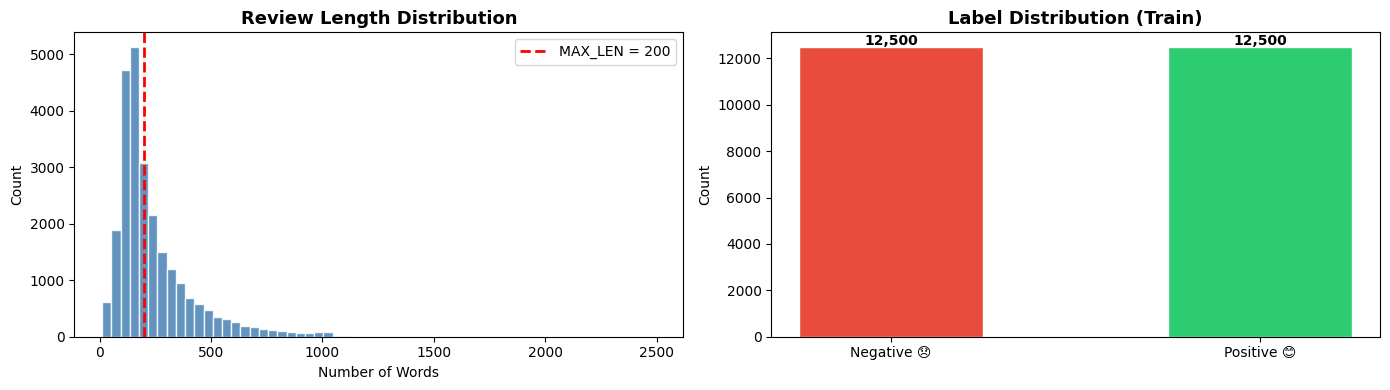

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))


axes[0].hist(lengths, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN = {MAX_LEN}')
axes[0].set_title('Review Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Count')
axes[0].legend()


labels = ['Negative 😞', 'Positive 😊']
counts = np.bincount(y_train)
axes[1].bar(labels, counts, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_title('Label Distribution (Train)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:

word_index = imdb.get_word_index()


reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decode_review(encoded):
    """Convert integer sequence back to human-readable text."""
    return ' '.join(reverse_index.get(i, '?') for i in encoded)

# Show a sample
idx = 0
sentiment = '😊 POSITIVE' if y_train[idx] == 1 else '😞 NEGATIVE'
print(f"Sample Review #{idx} — Label: {sentiment}")
review_text = decode_review(X_train[idx])
# Show first 200 words
print(' '.join(review_text.split()[:80]) + '...')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Review #0 — Label: 😊 POSITIVE
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as...


## 🔧 Step 4: Preprocessing — Padding Sequences

CNNs require fixed-size inputs. We **pad** short reviews with zeros and **truncate** long ones.

In [6]:
X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Padding complete!")
print(f"   X_train shape : {X_train_pad.shape}  → (samples, sequence_length)")
print(f"   X_test  shape : {X_test_pad.shape}")
print()
print(f"   Coverage: sequences kept as-is (< {MAX_LEN} words): "
      f"{sum(l <= MAX_LEN for l in lengths)/len(lengths)*100:.1f}% of training data")

Padding complete!
   X_train shape : (25000, 200)  → (samples, sequence_length)
   X_test  shape : (25000, 200)

   Coverage: sequences kept as-is (< 200 words): 57.3% of training data


In [7]:
def build_kim_cnn(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = EMBED_DIM,
    max_len      = MAX_LEN,
    filter_sizes = FILTER_SIZES,
    num_filters  = NUM_FILTERS,
    dropout_rate = DROPOUT_RATE,
):
    """
    Kim (2014) CNN for Sentence Classification.

    Uses the 'CNN-rand' variant: randomly initialised,
    fully trainable embeddings.
    """

    inputs = keras.Input(shape=(max_len,), name='input_sequence')


    x = layers.Embedding(
        input_dim    = vocab_size,
        output_dim   = embed_dim,
        input_length = max_len,
        name         = 'embedding'
    )(inputs)

    pooled_outputs = []

    for fs in filter_sizes:

        conv = layers.Conv1D(
            filters     = num_filters,
            kernel_size = fs,
            activation  = 'relu',
            name        = f'conv_{fs}gram'
        )(x)

        pool = layers.GlobalMaxPooling1D(name=f'maxpool_{fs}gram')(conv)


        pooled_outputs.append(pool)


    if len(pooled_outputs) > 1:
        concat = layers.Concatenate(name='concat_features')(pooled_outputs)
    else:
        concat = pooled_outputs[0]


    x = layers.Dropout(dropout_rate, name='dropout')(concat)


    outputs = layers.Dense(
        1,
        activation          = 'sigmoid',
        kernel_regularizer  = keras.regularizers.l2(1e-4),
        name                = 'output'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name='Kim2014_CNN')
    return model


# Build the model
model = build_kim_cnn()

# Compile
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

Model: "Kim2014_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,280,000 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3gram (Conv1D) │ (None, 198, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4gram (Conv1D) │ (None, 197, 128)  │     65,664 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5gram (Conv1D) │ (None, 196, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_3gram       │ (None, 128)       │          0 │ conv_3gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_4gram       │ (None, 128)       │          0 │ conv_4gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5gram       │ (None, 128)       │          0 │ conv_5gram[0][0]  │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_features     │ (None, 384)       │          0 │ maxpool_3gram[0]… │
│ (Concatenate)       │                   │            │ maxpool_4gram[0]… │
│                     │                   │            │ maxpool_5gram[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 384)       │          0 │ concat_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,477,377 (5.64 MB)

 Trainable params: 1,477,377 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:

total_params = model.count_params()
print("\nParameter Breakdown:")
print(f"   Embedding layer    : {VOCAB_SIZE} × {EMBED_DIM} = {VOCAB_SIZE * EMBED_DIM:,} params")
for fs in FILTER_SIZES:
    p = (EMBED_DIM * fs + 1) * NUM_FILTERS
    print(f"   Conv (filter={fs})    : ({EMBED_DIM}×{fs}+1)×{NUM_FILTERS} = {p:,} params")
print(f"   Output Dense : {NUM_FILTERS * len(FILTER_SIZES) + 1} params")
print(f"   TOTAL   : {total_params:,} params")


Parameter Breakdown:
   Embedding layer    : 10000 × 128 = 1,280,000 params
   Conv (filter=3)    : (128×3+1)×128 = 49,280 params
   Conv (filter=4)    : (128×4+1)×128 = 65,664 params
   Conv (filter=5)    : (128×5+1)×128 = 82,048 params
   Output Dense : 385 params
   TOTAL   : 1,477,377 params


## 🚀 Step 6: Train the Model

In [9]:

callbacks = [

    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 3,
        restore_best_weights = True,
        verbose   = 1
    ),

    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 2,
        min_lr    = 1e-6,
        verbose   = 1
    )
]


print("Starting training...")
print(f"   Training on {len(X_train_pad):,} samples")
print(f"   Validating on {len(X_test_pad):,} samples")
print()

history = model.fit(
    X_train_pad, y_train,
    batch_size        = BATCH_SIZE,
    epochs            = EPOCHS,
    validation_data   = (X_test_pad, y_test),
    callbacks         = callbacks,
    verbose           = 1
)

Starting training...
   Training on 25,000 samples
   Validating on 25,000 samples

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6761 - loss: 0.5752 - val_accuracy: 0.8476 - val_loss: 0.3446 - learning_rate: 0.0010
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8620 - loss: 0.3182 - val_accuracy: 0.8528 - val_loss: 0.3396 - learning_rate: 0.0010
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9168 - loss: 0.2107 - val_accuracy: 0.8546 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9554 - loss: 0.1254
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9554 - loss: 0.1254 - val_accuracy: 0.8470 - val_loss: 0.4292 - learning_rate: 0.0010
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9801 - loss: 0.0658 - val_accuracy: 0.8496 - val_loss: 0.4556 - learning_rate: 5.0000

## 📈 Step 7: Plot Training Curves

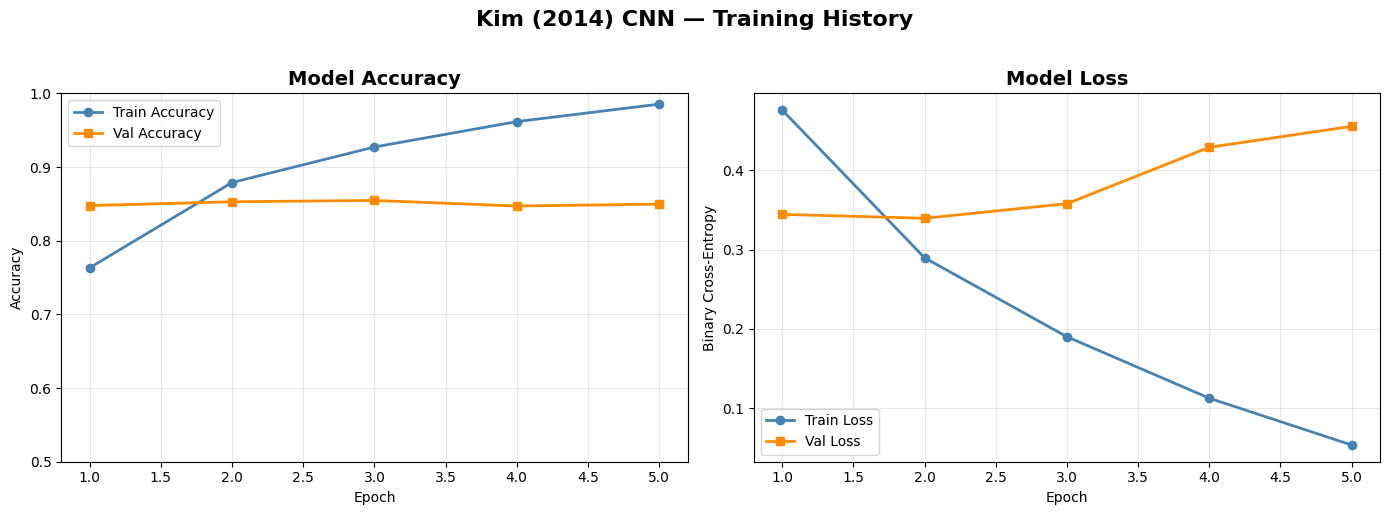

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'],     'o-', color='steelblue',  label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], 's-', color='darkorange', label='Val Accuracy',   linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(True, alpha=0.3)


axes[1].plot(epochs_ran, history.history['loss'],     'o-', color='steelblue',  label='Train Loss', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], 's-', color='darkorange', label='Val Loss',   linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Kim (2014) CNN — Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📊 Step 8: Evaluate on Test Set

In [11]:

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print("TEST SET RESULTS")
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")


y_pred_proba = model.predict(X_test_pad, verbose=0).flatten()   # probabilities
y_pred       = (y_pred_proba >= 0.5).astype(int)                # binary labels


auc = roc_auc_score(y_test, y_pred_proba)
print(f"  AUC-ROC  : {auc:.4f}")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative 😞', 'Positive 😊']))

TEST SET RESULTS
  Loss     : 0.3396
  Accuracy : 0.8528  (85.28%)
  AUC-ROC  : 0.9371

Classification Report:
              precision    recall  f1-score   support

  Negative 😞       0.82      0.90      0.86     12500
  Positive 😊       0.89      0.80      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



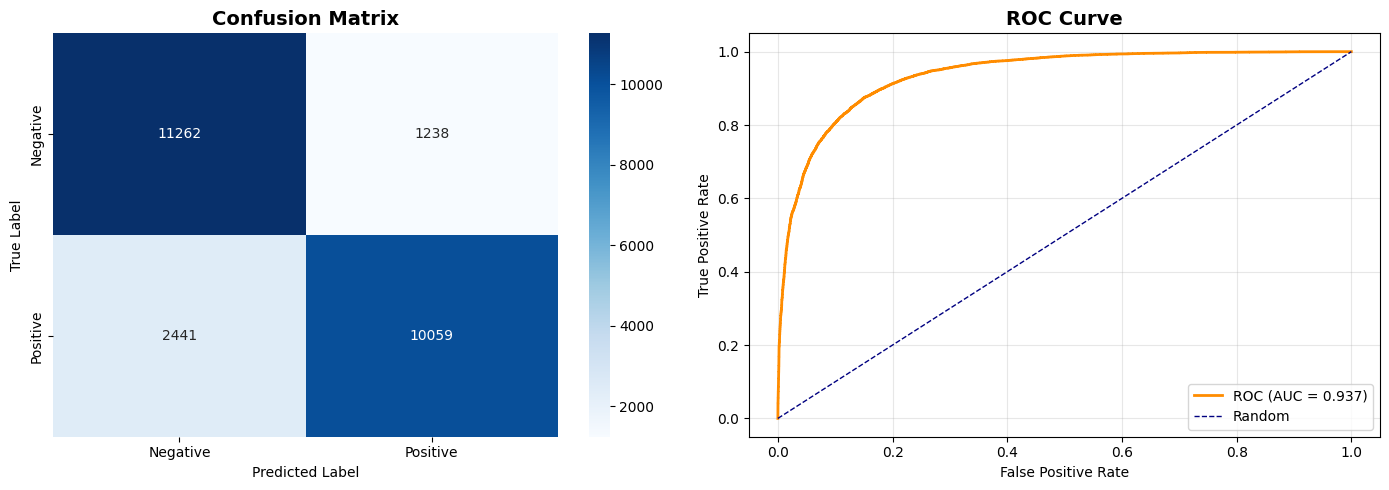

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], color='navy', lw=1, linestyle='--', label='Random')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔮 Step 9: Predict on Custom Reviews

Test the model on **your own sentences**!

In [13]:
def preprocess_custom_review(text, word_index, max_len=MAX_LEN, vocab_size=VOCAB_SIZE):
    """
    Convert a raw string review into a padded integer sequence
    matching the format the model was trained on.
    """
    # Lowercase and split
    words = text.lower().split()

    # Convert words to indices
    # Word index offset: actual words start at index 3 in the dataset
    # Index 0=pad, 1=start, 2=unk, so real words have +3 offset
    encoded = [
        min(word_index.get(w, 1) + 3, vocab_size - 1)   # 1=unk if word not found
        for w in words
    ]

    # Pad to max_len
    padded = pad_sequences([encoded], maxlen=max_len, padding='post', truncating='post')
    return padded


def predict_sentiment(text, threshold=0.5):
    """
    Predict the sentiment of a movie review.

    Returns:
        label       : 'POSITIVE' or 'NEGATIVE'
        confidence  : probability of positive class (0–1)
        sentiment_score: 0-100 score (50 = neutral)
    """
    # Preprocess
    padded = preprocess_custom_review(text, word_index)

    # Predict
    prob = float(model.predict(padded, verbose=0)[0][0])

    # Interpret
    if prob >= threshold:
        label = 'POSITIVE'
        emoji = '😊'
        bar_fill = int(prob * 30)
        bar = '█' * bar_fill + '░' * (30 - bar_fill)
    else:
        label = 'NEGATIVE'
        emoji = '😞'
        bar_fill = int((1 - prob) * 30)
        bar = '░' * (30 - bar_fill) + '█' * bar_fill

    print(f"Review  : {text[:80]}{'...' if len(text) > 80 else ''}")
    print(f"Result  : {emoji}  {label}")
    print(f"Confidence (positive) : {prob:.4f} ({prob*100:.1f}%)")
    print(f"[{bar}] {label}")
    print()
    return label, prob


print("Prediction function ready! See examples below.")

Prediction function ready! See examples below.


In [14]:


test_reviews = [
    # --- Clearly POSITIVE ---
    "This movie was absolutely fantastic! The acting was superb and the story was deeply moving. I loved every minute of it.",
    "One of the best films I have ever seen. Brilliant direction, powerful performances, and a beautiful soundtrack.",
    "A masterpiece of cinema. The characters were so well developed and the plot was gripping from start to finish.",

    # --- Clearly NEGATIVE ---
    "This was a complete waste of time. Terrible acting, boring plot, and predictable ending. I want my money back.",
    "Horrible film. The dialogue was awful and none of the characters were believable. One of the worst movies ever made.",
    "I fell asleep halfway through. Nothing made sense and the special effects looked cheap and outdated.",

    # --- Mixed / Ambiguous ---
    "The film had some great visuals but the story was quite disappointing. Not terrible but not great either.",
    "I expected more after all the hype. It was okay I guess, nothing special but not unwatchable.",
]


print(" SENTIMENT PREDICTIONS")


for i, review in enumerate(test_reviews, 1):
    print(f"\n[Review {i}]")
    predict_sentiment(review)
    print("-"*65)

 SENTIMENT PREDICTIONS

[Review 1]
Review  : This movie was absolutely fantastic! The acting was superb and the story was dee...
Result  : 😊  POSITIVE
Confidence (positive) : 0.9684 (96.8%)
[█████████████████████████████░] POSITIVE

-----------------------------------------------------------------

[Review 2]
Review  : One of the best films I have ever seen. Brilliant direction, powerful performanc...
Result  : 😊  POSITIVE
Confidence (positive) : 0.9908 (99.1%)
[█████████████████████████████░] POSITIVE

-----------------------------------------------------------------

[Review 3]
Review  : A masterpiece of cinema. The characters were so well developed and the plot was ...
Result  : 😊  POSITIVE
Confidence (positive) : 0.9697 (97.0%)
[█████████████████████████████░] POSITIVE

-----------------------------------------------------------------

[Review 4]
Review  : This was a complete waste of time. Terrible acting, boring plot, and predictable...
Result  : 😞  NEGATIVE
Confidence (positive)

In [15]:
your_review = "The movie started slow but built into something truly remarkable. I was moved to tears by the end."

print("YOUR REVIEW PREDICTION")
predict_sentiment(your_review)

YOUR REVIEW PREDICTION
Review  : The movie started slow but built into something truly remarkable. I was moved to...
Result  : 😊  POSITIVE
Confidence (positive) : 0.6711 (67.1%)
[████████████████████░░░░░░░░░░] POSITIVE



('POSITIVE', 0.6711133122444153)